<a href="https://colab.research.google.com/github/mikaeladepaula/desafio-alura-store/blob/main/AluraStoreBrasil_An%C3%A1lise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importação dos dados



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


In [3]:
# Nomeando cada uma das lojas
loja['Loja'] = 'Loja 1'
loja2['Loja'] = 'Loja 2'
loja3['Loja'] = 'Loja 3'
loja4['Loja'] = 'Loja 4'

# Juntar todas em um único lugar chamado 'df_total'
df_total = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)

# Validação
df_total.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,Loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1


#1. Análise do faturamento



In [4]:
# Soma do preço de tudo que cada loja vendeu
faturamento_por_loja = df_total.groupby('Loja')['Preço'].sum()

# Mostrar o resultado na tela
print("Faturamento de cada loja:")
print(faturamento_por_loja)


Faturamento de cada loja:
Loja
Loja 1    1534509.12
Loja 2    1488459.06
Loja 3    1464025.03
Loja 4    1384497.58
Name: Preço, dtype: float64


# 2. Vendas por Categoria

In [5]:
# Contagem de quantos produtos de cada categoria foram vendidos em cada loja
vendas_categoria = df_total.groupby(['Loja', 'Categoria do Produto']).size().unstack(fill_value=0)

print("Quantidade de vendas por categoria:")
vendas_categoria


Quantidade de vendas por categoria:


Categoria do Produto,brinquedos,eletrodomesticos,eletronicos,esporte e lazer,instrumentos musicais,livros,moveis,utilidades domesticas
Loja,,,,,,,,
Loja 1,324,312,448,284,182,173,465,171
Loja 2,313,305,422,275,224,197,442,181
Loja 3,315,278,451,277,177,185,499,177
Loja 4,338,254,451,277,170,187,480,201


# 3. Média de Avaliação das Lojas


In [6]:
# Cálculo da nota média (1 a 5) dada pelos clientes
media_notas = df_total.groupby('Loja')['Avaliação da compra'].mean()

print("Nota média de satisfação dos clientes (1 a 5):")
print(media_notas)

Nota média de satisfação dos clientes (1 a 5):
Loja
Loja 1    3.976685
Loja 2    4.037304
Loja 3    4.048326
Loja 4    3.995759
Name: Avaliação da compra, dtype: float64


# 4. Produtos Mais e Menos Vendidos

In [7]:
# Lista dos produtos mais e menos vendidos por loja
for l in ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']:
    contagem = df_total[df_total['Loja'] == l]['Produto'].value_counts()
    print(f"--- {l} ---")
    print(f"Mais vendido: {contagem.idxmax()} ({contagem.max()} vendas)")
    print(f"Menos vendido: {contagem.idxmin()} ({contagem.min()} vendas)")
    print("-" * 20)

--- Loja 1 ---
Mais vendido: Micro-ondas (60 vendas)
Menos vendido: Headset (33 vendas)
--------------------
--- Loja 2 ---
Mais vendido: Iniciando em programação (65 vendas)
Menos vendido: Jogo de tabuleiro (32 vendas)
--------------------
--- Loja 3 ---
Mais vendido: Kit banquetas (57 vendas)
Menos vendido: Blocos de montar (35 vendas)
--------------------
--- Loja 4 ---
Mais vendido: Cama box (62 vendas)
Menos vendido: Guitarra (33 vendas)
--------------------


# 5. Frete Médio por Loja

In [8]:
# Cálculo da média da coluna 'Frete' para cada loja
frete_medio = df_total.groupby('Loja')['Frete'].mean()

print("Custo médio de frete por loja (em Reais):")
print(frete_medio)

Custo médio de frete por loja (em Reais):
Loja
Loja 1    34.691805
Loja 2    33.621941
Loja 3    33.074464
Loja 4    31.278997
Name: Frete, dtype: float64


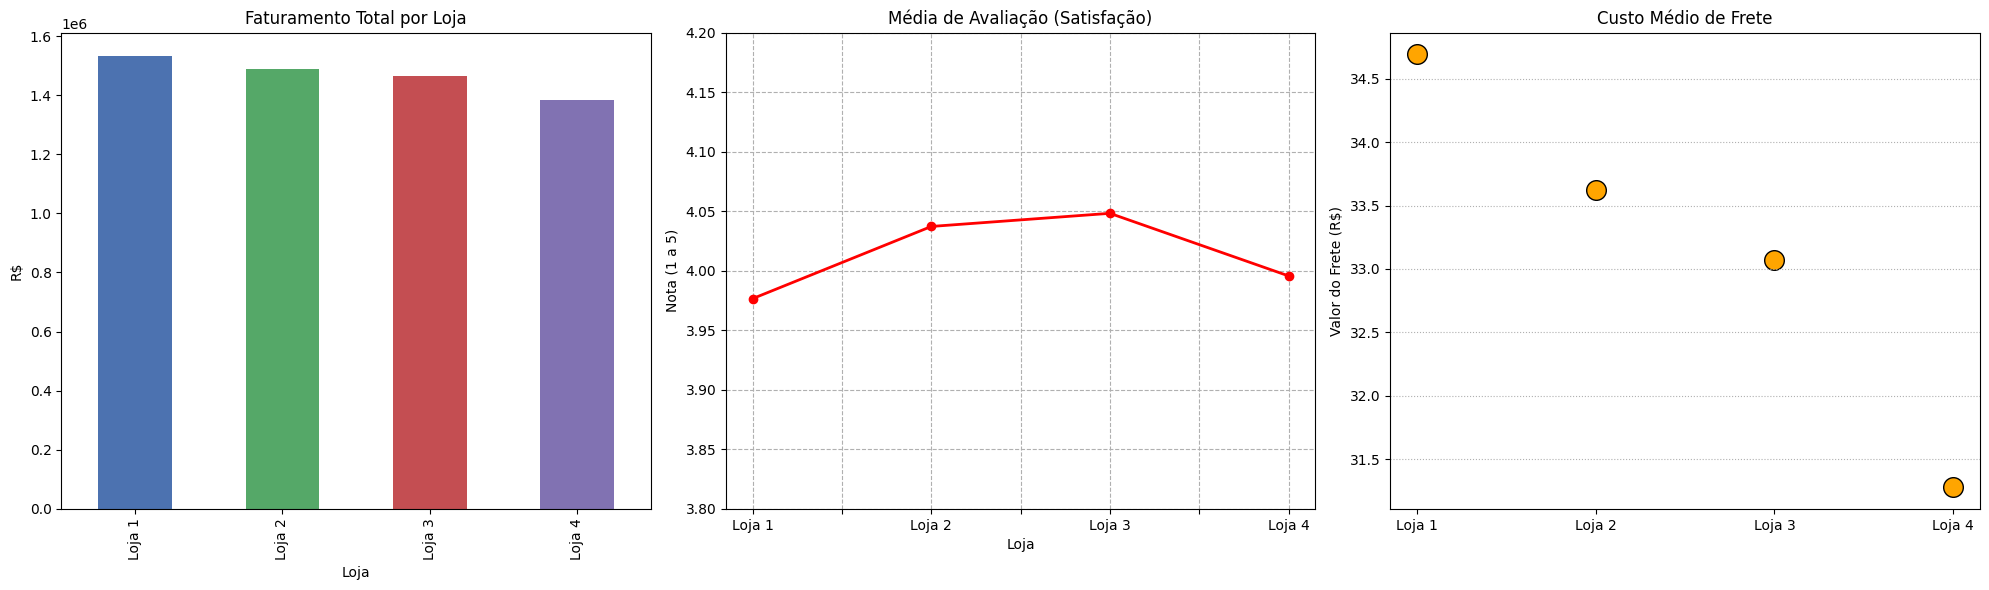

In [9]:
import matplotlib.pyplot as plt

# Criar uma área para 3 gráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico 1: Barras para o Faturamento
faturamento_por_loja.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
axes[0].set_title('Faturamento Total por Loja')
axes[0].set_ylabel('R$')
axes[0].set_xlabel('Loja')

# Gráfico 2: Linha para as Avaliações (Satisfação)
media_notas.plot(kind='line', ax=axes[1], marker='o', color='red', linewidth=2)
axes[1].set_title('Média de Avaliação (Satisfação)')
axes[1].set_ylabel('Nota (1 a 5)')
axes[1].set_ylim(3.8, 4.2) # Ajuste para ver melhor a diferença
axes[1].grid(True, linestyle='--')

# Gráfico 3: Dispersão (Bolinhas) para o Frete
axes[2].scatter(frete_medio.index, frete_medio.values, s=200, color='orange', edgecolor='black')
axes[2].set_title('Custo Médio de Frete')
axes[2].set_ylabel('Valor do Frete (R$)')
axes[2].grid(axis='y', linestyle=':')

plt.tight_layout()
plt.show()

# Relatório de Consultoria: Recomendação de Venda - Alura Store

---

## 1. Objetivo
O presente relatório visa analisar o desempenho das quatro unidades da **Alura Store Brasil** para identificar qual delas apresenta a menor eficiência operacional e financeira, subsidiando a decisão do Senhor João sobre qual unidade vender para iniciar seu novo empreendimento.

---

## 2. Análise dos Indicadores
Com base no processamento e análise dos dados de vendas, observamos os seguintes pontos críticos:

* **Desempenho Financeiro:** A **Loja 4** apresentou o menor faturamento total da rede (1.384.497,58 reais), ficando aproximadamente 150.000,00 reais abaixo da Loja 1, que é a líder em vendas.
* **Satisfação do Cliente:** Embora as médias de satisfação sejam próximas, a **Loja 1** detém a menor nota média (**3.97**), seguida de perto pela **Loja 4** (**3.99**). Em contraste, as Lojas 2 e 3 superam a marca de 4.0, indicando maior fidelidade dos clientes.
* **Logística (Frete):** A **Loja 4** possui o frete médio mais baixo da rede (**R$ 31,27**). Este é um dado alarmante, pois indica que, mesmo com a vantagem competitiva de ter a entrega mais barata, a loja não consegue converter esse benefício em um volume de faturamento expressivo.
* **Mix de Produtos:** A Loja 4 tem como destaque de vendas a categoria de móveis (**Cama box**), porém apresenta o menor volume de vendas em instrumentos musicais de toda a rede.

---

## 3. Recomendação Final
Com base nas análises técnicas e nos indicadores de desempenho apresentados, a recomendação estratégica ao Senhor João é que realize a **venda da Loja 4**.

### Justificativa:
Apesar de possuir o frete mais atrativo para o consumidor, a **Loja 4** consolidou-se como a unidade com o **menor faturamento total**. O fato de a unidade não liderar em vendas, mesmo com o menor custo logístico, sugere problemas estruturais na demanda local ou na incapacidade de conversão de clientes. Manter a operação da Loja 4 representa um **custo de oportunidade elevado** em comparação às outras unidades que entregam resultados financeiros superiores, mesmo operando com fretes mais caros.